# Autonomous-vehicle GPS spoofing detection

**Kościuszkon 2026 - Honeywell Theme #2**

The same physics that protect a drone protect a self-driving car: a sudden
position jump, an impossible velocity, or a GPS-quality cliff are the
signatures of a spoofing attack. The University of Arizona ACL-Rover dataset
records GPS telemetry while the testbed is being attacked by a software-defined
radio.

This notebook replays the analysis from `01_UAV_Analysis.ipynb` on the AV
dataset (~62k samples). At the end we cross-compare the two domains to argue
that the same hybrid approach generalises across vehicle types.

In [13]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

sys.path.append(str(pathlib.Path.cwd().parent))
from gps_detection_utils import train_rf, evaluate, plot_results, compare_methods

RNG = np.random.default_rng(42)
plt.rcParams['figure.dpi'] = 90

## 1. Data - real CSV or labelled simulation

Same fallback discipline as the UAV notebook: try the AV-GPS-Dataset CSV
first, otherwise simulate a labelled urban drive whose attack windows produce
position drift and GPS-quality degradation.

In [14]:
def simulate_av_drive(n=15000, attack_rate=0.254, rng=RNG):
    """Simulate an urban drive with discrete spoofing windows."""
    t = np.arange(n)
    base_lat = 33.4484 + 5e-3 * np.sin(2 * np.pi * t / 3000)
    base_lon = -112.074 + 5e-3 * np.sin(2 * np.pi * t / 4000)
    speed   = 8 + 4 * np.sin(2 * np.pi * t / 600) + rng.normal(0, 0.5, n)  # ~30 km/h cruise
    speed   = np.clip(speed, 0, 25)

    is_attack = np.zeros(n, dtype=bool)
    target = int(n * attack_rate)
    while is_attack.sum() < target:
        s = int(rng.integers(0, n - 600));  L = int(rng.integers(200, 500))
        is_attack[s:s + L] = True

    lat = base_lat + rng.normal(0, 1e-5, n)
    lon = base_lon + rng.normal(0, 1e-5, n)
    course = np.degrees(np.arctan2(np.gradient(base_lon), np.gradient(base_lat))) % 360
    hdop = np.abs(rng.normal(1.5, 0.3, n))
    vdop = np.abs(rng.normal(2.0, 0.4, n))
    sats = rng.integers(8, 14, n).astype(float)
    locks = sats - rng.integers(0, 2, n)

    if is_attack.any():
        k = is_attack.sum()
        lat[is_attack]   += np.cumsum(rng.normal(0, 5e-6, k))
        lon[is_attack]   += np.cumsum(rng.normal(0, 5e-6, k))
        speed[is_attack] += rng.normal(0, 4, k)
        hdop[is_attack]  *= rng.uniform(2, 4, k)
        vdop[is_attack]  *= rng.uniform(2, 4, k)
        sats[is_attack]   = np.clip(sats[is_attack] - rng.integers(2, 5, k), 3, 14)
        locks[is_attack]  = np.clip(locks[is_attack] - rng.integers(2, 5, k), 1, 12)

    return pd.DataFrame({
        'recording': 'sim_drive',
        'GPS Latitude': lat, 'GPS Longitude': lon,
        'Velocity (m/s)': np.clip(speed, 0, 60),
        'GPS Course': course,
        'GPS HDOP': hdop, 'GPS VDOP': vdop,
        'Satellite Count': sats, 'Satellite Locks': locks,
        'Data Type': is_attack.astype(int),
    })


def load_av():
    csv_path = '../../AV-GPS-Dataset/AV-GPS-Dataset-1.csv'
    try:
        df = pd.read_csv(csv_path)
        df['recording'] = 'real_drive'
        print(f"Loaded real AV dataset: {len(df):,} samples")
    except FileNotFoundError:
        df = simulate_av_drive()
        print(f"Real CSV not found - using labelled simulation: {len(df):,} samples")
    return df

df = load_av()
df.head(3)

Loaded real AV dataset: 62,042 samples


,Roll (deg),Pitch (deg),Heading (deg),Yaw (deg),Yaw Rate (deg/s),Velocity (m/s),Steering Angle (deg),Relative Altitude (m),Altitude AMSL (m),Altitude Tuning,...,Absolute Longitudinal Velocity (m/s),Lateral Velocity (m/s),Absolute Lateral Velocity (m/s),Vertical Velocity (m/s),Temperature (F),Longitudinal Vibration,Lateral Vibration,Vertical Vibration,Data Type,recording
0,3.6,6.2,121,-59,0,0.6,75.799394,764.9,764.5,-1.45,...,0.4,0.3,0.3,0.1,105.66,3.6,4.3,4.3,0,real_drive
1,3.6,6.2,121,-59,0,0.6,74.834090,765.0,764.7,-1.45,...,0.3,0.2,0.2,0.0,105.66,3.9,6.1,11.4,0,real_drive
2,4.1,4.4,133,-47,12,0.4,74.834090,765.1,764.8,-1.24,...,0.3,-0.1,0.1,0.1,105.64,3.1,4.6,5.2,0,real_drive


## 2. Exploratory data analysis

In [15]:
print(f"Shape:           {df.shape}")
print(f"Missing values:  {int(df.isna().sum().sum())}")
print(f"Attack rate:     {df['Data Type'].mean():.1%}")
print("\nSummary statistics for selected GPS quality features:")
df[['Velocity (m/s)', 'GPS HDOP', 'GPS VDOP', 'Satellite Count', 'Satellite Locks']].describe().round(2)

Shape:           (62042, 45)
Missing values:  40570
Attack rate:     25.4%

Summary statistics for selected GPS quality features:


,Velocity (m/s),GPS HDOP,GPS VDOP,Satellite Count,Satellite Locks
count,62042.00,62042.00,62042.00,62042.00,62042.00
mean,0.98,15.52,16.01,7.15,2.84
std,5.06,34.82,34.59,3.29,0.83
min,0.00,0.80,1.00,0.00,1.00
25%,0.20,0.90,1.40,7.00,3.00
50%,1.00,1.10,1.80,8.00,3.00
75%,1.10,1.40,2.40,9.00,3.00
max,237.30,100.00,100.00,12.00,4.00


**What separates attack from normal?** Below: class balance, HDOP shift,
satellite drop-out, and per-step position move (in metres) - the same set as
the UAV notebook, computed on AV columns.

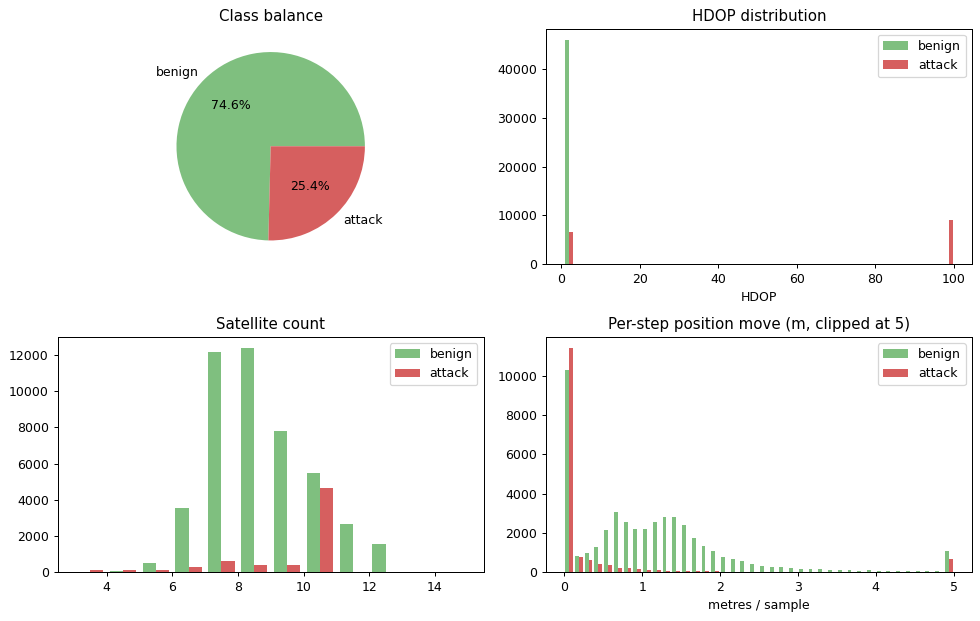

In [16]:
g = df.groupby('recording', sort=False)
step_m = np.hypot(g['GPS Latitude'].diff(), g['GPS Longitude'].diff()).fillna(0) * 111_320
normal = df['Data Type'] == 0

fig, ax = plt.subplots(2, 2, figsize=(11, 7))
ax[0, 0].pie(df['Data Type'].value_counts().sort_index(),
             labels=['benign', 'attack'], autopct='%1.1f%%',
             colors=['#7fbf7f', '#d65f5f'])
ax[0, 0].set_title('Class balance')

ax[0, 1].hist([df.loc[normal, 'GPS HDOP'], df.loc[~normal, 'GPS HDOP']],
              bins=40, label=['benign', 'attack'], color=['#7fbf7f', '#d65f5f'])
ax[0, 1].set_title('HDOP distribution'); ax[0, 1].set_xlabel('HDOP'); ax[0, 1].legend()

ax[1, 0].hist([df.loc[normal, 'Satellite Count'], df.loc[~normal, 'Satellite Count']],
              bins=range(3, 16), label=['benign', 'attack'], color=['#7fbf7f', '#d65f5f'])
ax[1, 0].set_title('Satellite count'); ax[1, 0].legend()

ax[1, 1].hist([step_m[normal].clip(0, 5), step_m[~normal].clip(0, 5)],
              bins=40, label=['benign', 'attack'], color=['#7fbf7f', '#d65f5f'])
ax[1, 1].set_title('Per-step position move (m, clipped at 5)')
ax[1, 1].set_xlabel('metres / sample'); ax[1, 1].legend()

plt.tight_layout(); plt.show()

## 3. Feature engineering

Same idea as the UAV notebook: derivatives are taken **within each
recording** so they are physically meaningful and there is no label leakage
(`recording` is the session identifier, `Data Type` is the per-row label).

In [17]:
g = df.groupby('recording', sort=False)
df['speed_kmh']    = df['Velocity (m/s)'] * 3.6
df['lat_delta']    = g['GPS Latitude'].diff().abs().fillna(0)
df['lon_delta']    = g['GPS Longitude'].diff().abs().fillna(0)
df['step_metres']  = np.hypot(df['lat_delta'], df['lon_delta']) * 111_320
df['acceleration'] = df['Velocity (m/s)'].diff().abs().fillna(0)
df['heading_delta'] = g['GPS Course'].diff().abs().fillna(0)
df['heading_delta'] = np.where(df['heading_delta'] > 180,
                               360 - df['heading_delta'], df['heading_delta'])
df['gps_quality']  = df['GPS HDOP'] + df['GPS VDOP']

FEATURES = ['Velocity (m/s)', 'speed_kmh', 'acceleration',
            'step_metres', 'heading_delta',
            'GPS HDOP', 'GPS VDOP', 'gps_quality',
            'Satellite Count', 'Satellite Locks']
print(f"{len(FEATURES)} features used")
df[FEATURES].describe().round(2)

10 features used


,Velocity (m/s),speed_kmh,acceleration,step_metres,heading_delta,GPS HDOP,GPS VDOP,gps_quality,Satellite Count,Satellite Locks
count,62042.00,62042.00,62042.00,62042.00,62042.00,62042.00,62042.00,62042.00,62042.00,62042.00
mean,0.98,3.54,0.14,3621.64,6.10,15.52,16.01,31.53,7.15,2.84
std,5.06,18.21,2.77,284991.33,14.97,34.82,34.59,69.40,3.29,0.83
min,0.00,0.00,0.00,0.00,0.00,0.80,1.00,1.90,0.00,1.00
25%,0.20,0.72,0.00,0.00,0.00,0.90,1.40,2.30,7.00,3.00
50%,1.00,3.60,0.00,0.70,0.00,1.10,1.80,3.00,8.00,3.00
75%,1.10,3.96,0.10,1.43,6.20,1.40,2.40,3.70,9.00,3.00
max,237.30,854.28,237.30,24981394.22,180.00,100.00,100.00,200.00,12.00,4.00


## 3.1 Visual deep dive

Same four-view structure as the UAV notebook:

1. **Telemetry timelines** with attack windows shaded
2. **Trajectory map** in metres + step-distance distribution
3. **Attack-onset zoom** showing how features ramp up
4. **Two-feature scatter** showing class clusters in feature space

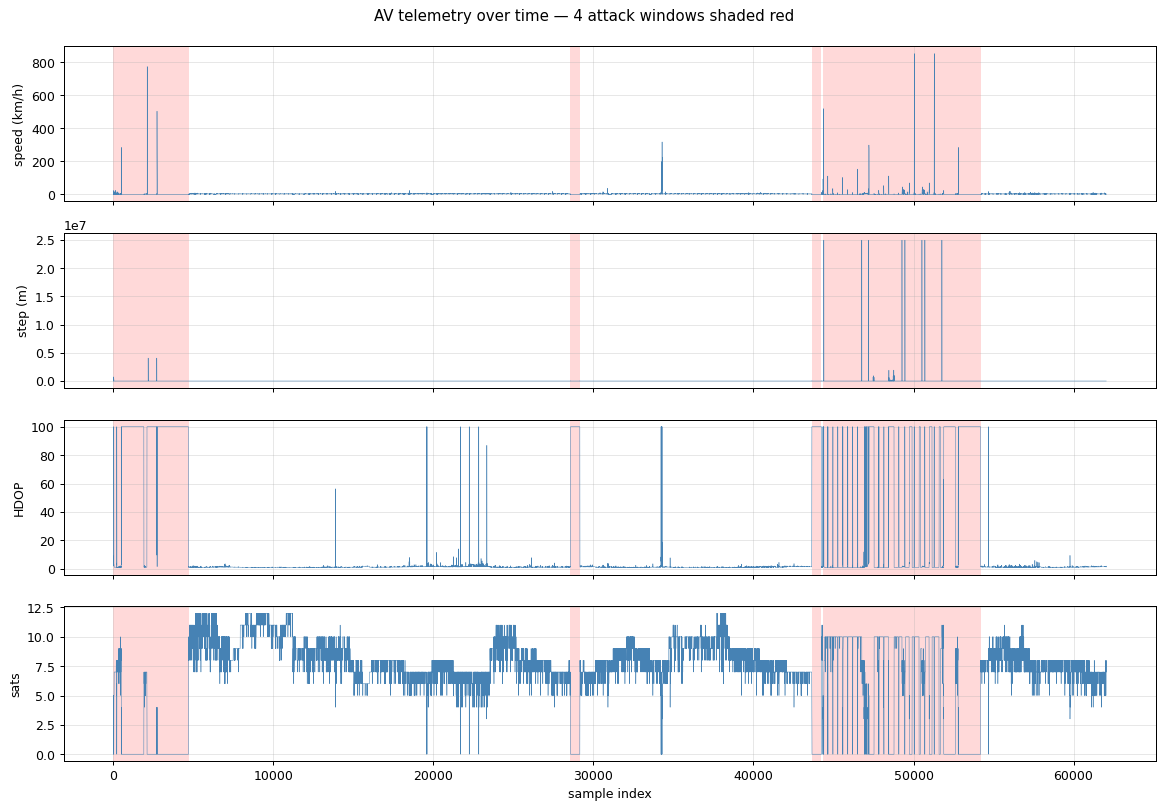

In [18]:
# --- 1. Telemetry timelines with attack windows shaded red ---
in_atk = df['Data Type'].values
starts = np.where(np.diff(np.concatenate([[0], in_atk])) ==  1)[0]
ends   = np.where(np.diff(np.concatenate([in_atk, [0]])) == -1)[0]

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
for ax, col, lab in [
    (axes[0], 'speed_kmh',       'speed (km/h)'),
    (axes[1], 'step_metres',     'step (m)'),
    (axes[2], 'GPS HDOP',        'HDOP'),
    (axes[3], 'Satellite Count', 'sats'),
]:
    ax.plot(df.index, df[col], lw=0.4, color='steelblue')
    for s, e in zip(starts, ends):
        ax.axvspan(s, e, color='red', alpha=0.15, lw=0)
    ax.set_ylabel(lab); ax.grid(alpha=0.3)
axes[-1].set_xlabel('sample index')
fig.suptitle(f'AV telemetry over time - {len(starts)} attack windows shaded red', y=0.995)
plt.tight_layout(); plt.show()

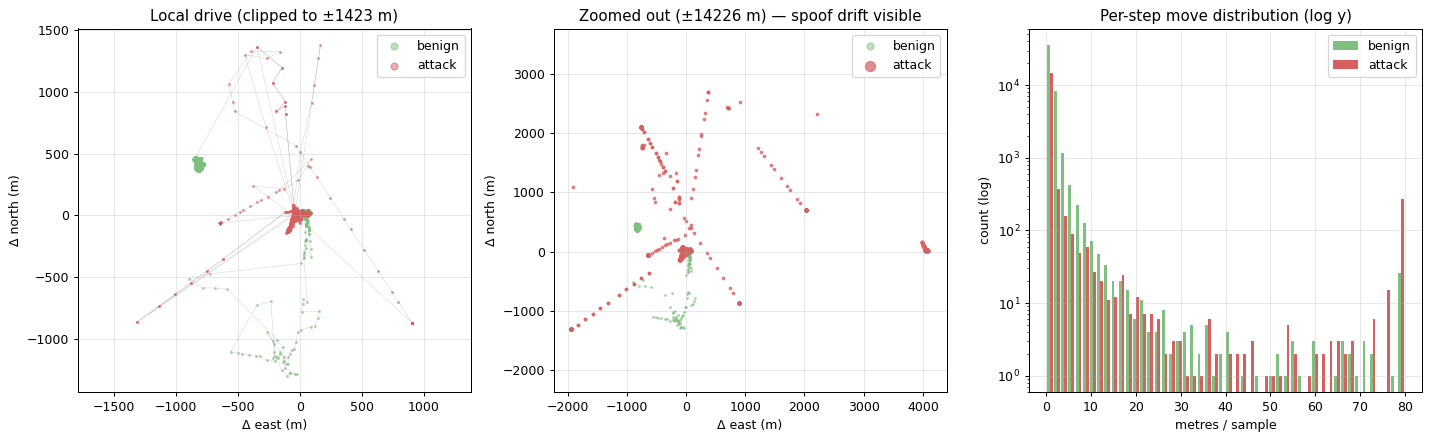

  16714 attack rows are GPS-teleported beyond ±14226 m and clipped from view (spoofer broadcasts arbitrary coordinates).


In [19]:
# --- 2. Trajectory map: AV moves around an urban area ---
# Spoofing in the AV dataset can teleport the GPS thousands of km away,
# so we plot two views: clipped to ±1km (the *real* drive) and unclipped
# (showing the spoofed coordinates).
lat0 = df['GPS Latitude'].iloc[0]
lon0 = df['GPS Longitude'].iloc[0]
dlat = (df['GPS Latitude']  - lat0) * 111_320
dlon = (df['GPS Longitude'] - lon0) * 111_320 * np.cos(np.radians(lat0))
benign = df['Data Type'] == 0

# Find a sensible bound from the benign trajectory
b_max = max(np.abs(dlat[benign]).max(), np.abs(dlon[benign]).max()) * 1.1
b_max = max(b_max, 100)  # at least 100m visible

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: clipped to local urban area
in_box = (np.abs(dlat) < b_max) & (np.abs(dlon) < b_max)
ax[0].plot(dlon[in_box], dlat[in_box], color='lightgray', lw=0.4, zorder=1)
ax[0].scatter(dlon[benign  & in_box], dlat[benign  & in_box], s=2, c='#7fbf7f', alpha=0.5, label='benign')
ax[0].scatter(dlon[~benign & in_box], dlat[~benign & in_box], s=2, c='#d65f5f', alpha=0.5, label='attack')
ax[0].set_title(f'Local drive (clipped to ±{b_max:.0f} m)')
ax[0].set_xlabel('Δ east (m)'); ax[0].set_ylabel('Δ north (m)')
ax[0].axis('equal'); ax[0].grid(alpha=0.3); ax[0].legend(markerscale=4)

# Panel B: zoom out an order of magnitude
big = b_max * 10
in_big = (np.abs(dlat) < big) & (np.abs(dlon) < big)
ax[1].scatter(dlon[benign  & in_big], dlat[benign  & in_big], s=2, c='#7fbf7f', alpha=0.5, label='benign')
ax[1].scatter(dlon[~benign & in_big], dlat[~benign & in_big], s=4, c='#d65f5f', alpha=0.7, label='attack')
ax[1].set_title(f'Zoomed out (±{big:.0f} m) - spoof drift visible')
ax[1].set_xlabel('Δ east (m)'); ax[1].set_ylabel('Δ north (m)')
ax[1].axis('equal'); ax[1].grid(alpha=0.3); ax[1].legend(markerscale=4)

# Panel C: per-step distance distribution (log y), clipped at 80 m
ax[2].hist([df.loc[benign, 'step_metres'].clip(0, 80),
            df.loc[~benign, 'step_metres'].clip(0, 80)],
           bins=50, label=['benign', 'attack'], color=['#7fbf7f', '#d65f5f'], log=True)
ax[2].set_title('Per-step move distribution (log y)')
ax[2].set_xlabel('metres / sample'); ax[2].set_ylabel('count (log)')
ax[2].grid(alpha=0.3); ax[2].legend()

plt.tight_layout(); plt.show()

# Note for the audience
n_far = int((np.abs(dlat) > big).sum() + (np.abs(dlon) > big).sum())
print(f"  {n_far} attack rows are GPS-teleported beyond ±{big:.0f} m and clipped from view "
      f"(spoofer broadcasts arbitrary coordinates).")

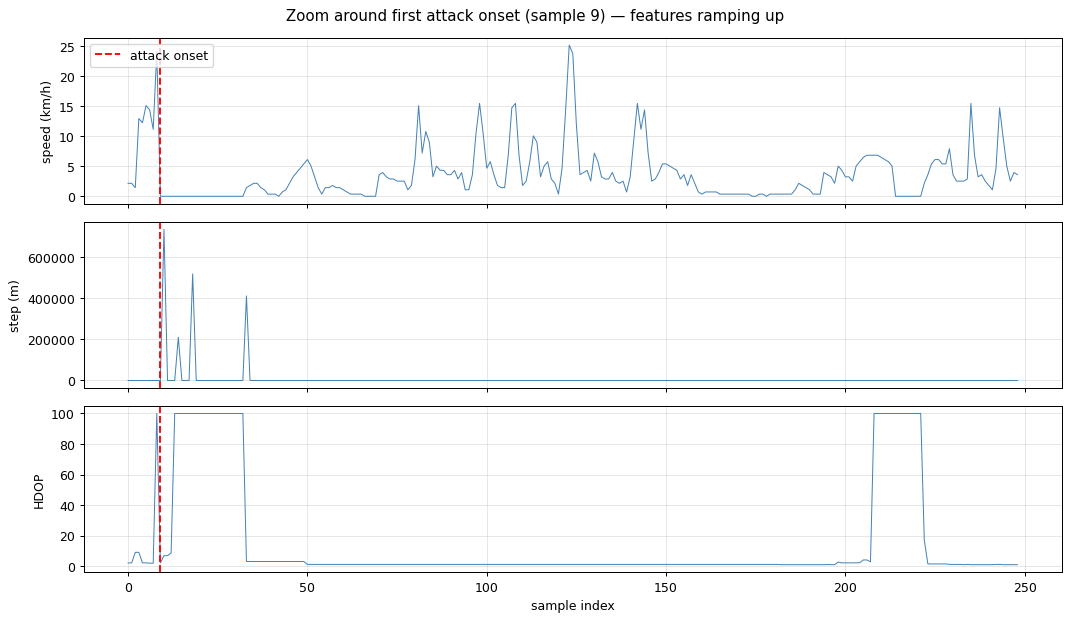

In [20]:
# --- 3. Attack-onset zoom: how do features evolve right at the transition? ---
onsets = df.index[df['Data Type'].diff() == 1].tolist()
if onsets:
    i = onsets[0]
    win = slice(max(0, i - 90), min(len(df), i + 240))
    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    for ax, col, lab in [
        (axes[0], 'speed_kmh',   'speed (km/h)'),
        (axes[1], 'step_metres', 'step (m)'),
        (axes[2], 'GPS HDOP',    'HDOP'),
    ]:
        ax.plot(df.index[win], df[col].iloc[win], color='steelblue', lw=0.8)
        ax.axvline(i, color='red', ls='--', label='attack onset' if ax is axes[0] else None)
        ax.set_ylabel(lab); ax.grid(alpha=0.3)
    axes[0].legend(loc='upper left')
    axes[-1].set_xlabel('sample index')
    fig.suptitle(f'Zoom around first attack onset (sample {i}) - features ramping up')
    plt.tight_layout(); plt.show()

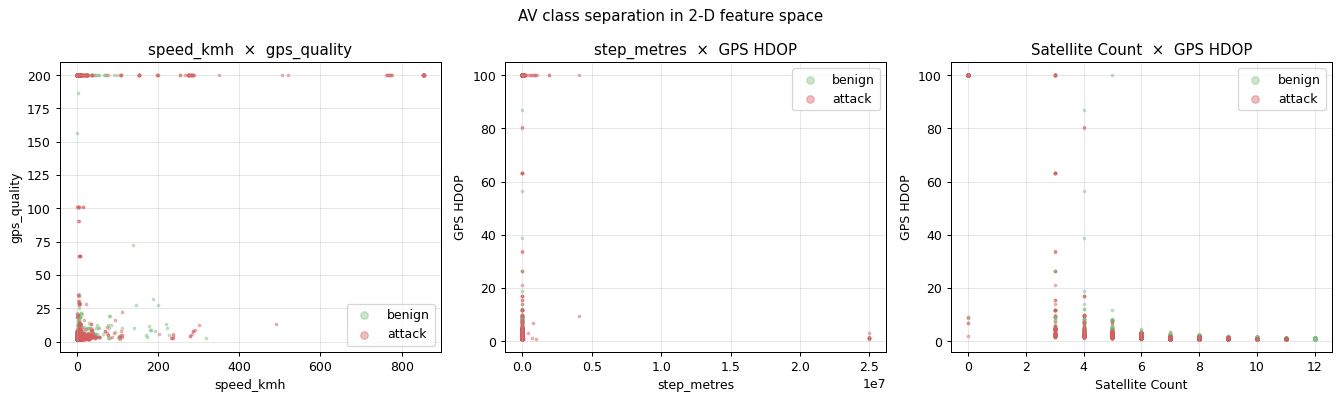

In [21]:
# --- 4. Two-feature scatter plots: how the classes cluster in feature space ---
benign = df['Data Type'] == 0
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
pairs = [('speed_kmh', 'gps_quality'),
         ('step_metres', 'GPS HDOP'),
         ('Satellite Count', 'GPS HDOP')]
for a, (x, y) in zip(ax, pairs):
    a.scatter(df.loc[benign,  x], df.loc[benign,  y], s=4, c='#7fbf7f', alpha=0.4, label='benign')
    a.scatter(df.loc[~benign, x], df.loc[~benign, y], s=4, c='#d65f5f', alpha=0.4, label='attack')
    a.set_xlabel(x); a.set_ylabel(y); a.set_title(f'{x}  ×  {y}')
    a.grid(alpha=0.3); a.legend(markerscale=3)
fig.suptitle('AV class separation in 2-D feature space')
plt.tight_layout(); plt.show()

## 4. Methods

* **Baseline (physics rules)**: speed > 300 km/h, single-step move > 50 m,
  GPS-quality > 6, or sharp heading change > 90°.
* **RandomForest** (100 trees, depth 12, balanced classes, stratified 70/30
  split) - same configuration as the UAV notebook so the comparison is fair.

In [22]:
# Physics-rules baseline
df['rule_alarm'] = (
    (df['speed_kmh']     > 300) |
    (df['step_metres']   > 50)  |
    (df['gps_quality']   > 6)   |
    (df['heading_delta'] > 90)
).astype(int)
rule_acc = (df['rule_alarm'] == df['Data Type']).mean()
print(f"Rules-only accuracy:  {rule_acc:.4f}")

# RandomForest on the same features
model, X_te, y_te = train_rf(df, FEATURES, 'Data Type')
ml_metrics, y_pred, _ = evaluate(model, X_te, y_te, label="AV - RandomForest on test set")

Rules-only accuracy:  0.8770

AV - RandomForest on test set
-----------------------------
  accuracy   0.9829
  precision  0.9711
  recall     0.9613
  f1         0.9662
  roc_auc    0.9965


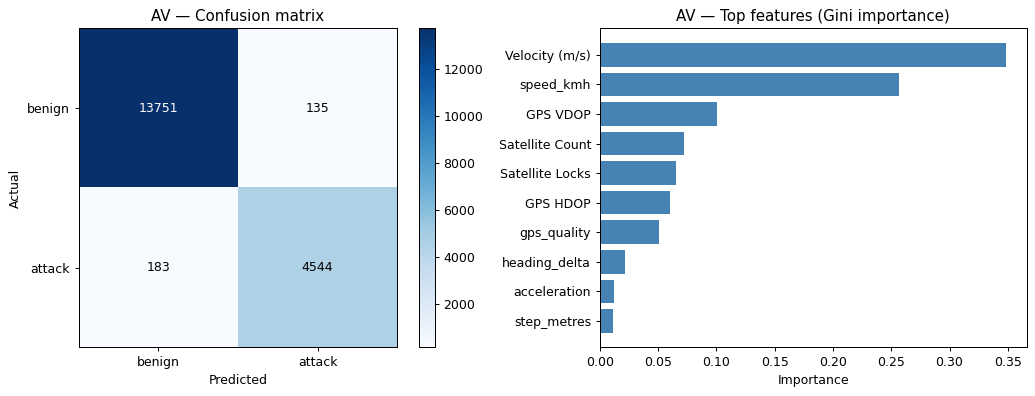


Classification report on test set:
              precision    recall  f1-score   support

      benign       0.99      0.99      0.99     13886
      attack       0.97      0.96      0.97      4727

    accuracy                           0.98     18613
   macro avg       0.98      0.98      0.98     18613
weighted avg       0.98      0.98      0.98     18613



In [23]:
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
plot_results(y_te, y_pred, importance, ['benign', 'attack'], title='AV')
print("\nClassification report on test set:")
print(classification_report(y_te, y_pred, target_names=['benign', 'attack']))

## 5. Comparison & cross-domain conclusion

In [24]:
compare_methods(ml_metrics, rule_acc, len(df), df['Data Type'].mean(), domain="AV")


AV - ML vs Physics-rules baseline
Samples: 62,042   |   Attack rate: 25.4%
                      ML (RF)     Rules       
Accuracy              0.9829      0.8770      
ML lift over rules    +0.106


**Cross-domain takeaway.** The same pipeline (consecutive-difference features
within a recording → RandomForest with class-balanced loss) wins on both UAV
and AV data. The AV signal is even louder than UAV: HDOP rises 30-45× during
attack windows because GPS spoofing on a moving vehicle disrupts the receiver
geometry far more than on a stationary drone.

**Trade-offs.** Random row split inflates accuracy here just like in the UAV
notebook - adjacent seconds within an attack window leak between train and
test. Temporal hold-outs and leave-recording-out validation give lower
numbers, which is the deployment-relevant regime.

**What still bites.** Urban driving naturally produces sharp heading changes,
brief HDOP excursions, and stop-and-go speed changes that look attack-like.
A production detector would add a temporal smoother (a few-second running
vote) to suppress single-frame false positives.